# Decision-Equivalent Conditioning for BO: a continuous-action symmetry toy

This notebook is a **small, human-readable demonstration** of the proposed screening idea.

We deliberately choose a simple 1D problem so that every object can be plotted and inspected. The structural information is a collection of nonlinear reflection-symmetry factors

\[
e_j(f)
=
\gamma \log\cosh\!\left(
\frac{f(r_j)-f(-r_j)}{\tau}
\right),
\]

so each factor couples two potentially distant input locations. This tests **function-space influence**, not just Euclidean locality.

The BO utility is

\[
u_x(f)=\exp(\beta f(x)),
\]

and we compare:

1. a **sparsely conditioned acquisition** using only an adaptively chosen subset of factors;
2. a cheap **optimistic challenger envelope** that upper-bounds what *all omitted factors* could do;
3. the fully conditioned acquisition, computed **only afterward** as held-out validation.

The algorithm is

\[
\boxed{
\text{optimize sparse acquisition}
\rightarrow
\text{find worst challenger}
\rightarrow
\text{add its most influential omitted factors}
\rightarrow
\text{repeat}
}
\]

and stops when the challenger envelope certifies that the current action is within a target \(\epsilon\) of the acquisition value that full conditioning could achieve.

> **Visualization choice.** The 1D action interval is represented by a dense grid of 401 actions. The theory only needs a maximizer of the challenger objective \(C_S(x)\), so a real continuous implementation would replace this grid argmax by a continuous optimizer and add its optimization/discretization error to the error budget. We never enumerate all pairs \((x,x')\).

## 1. The certificate in one equation

Let \(S\) be the active conditioning factors and \(U\) the omitted ones. Let

\[
\widehat x
=
\arg\max_x \alpha_S(x).
\]

For any challenger \(x\), suppose the structural screening theory gives

\[
\left|
\left[\log\alpha_{\rm full}(\widehat x)-\log\alpha_{\rm full}(x)\right]
-
\left[\log\alpha_S(\widehat x)-\log\alpha_S(x)\right]
\right|
\le B_S(\widehat x,x).
\]

Rearranging,

\[
\log\alpha_{\rm full}(x)-\log\alpha_{\rm full}(\widehat x)
\le
\underbrace{
\log\alpha_S(x)-\log\alpha_S(\widehat x)
+
B_S(\widehat x,x)
}_{C_S(x)}.
\]

Therefore

\[
\boxed{
\epsilon_S=\max_x C_S(x)
}
\]

implies

\[
\boxed{
\log\alpha_{\rm full}(x^\star_{\rm full})
-
\log\alpha_{\rm full}(\widehat x)
\le \epsilon_S.
}
\]

Equivalently,

\[
\alpha_{\rm full}(\widehat x)
\ge
e^{-\epsilon_S}\,
\alpha_{\rm full}(x^\star_{\rm full}).
\]

So we need **one leader** and **one worst-challenger maximization**, not all pairwise comparisons.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import logsumexp
from pathlib import Path

SEED = 123

# GP / symmetry-factor parameters
N_FACTORS = 40
DX = 0.05
ELL = 0.125
GAMMA = 0.05
TAU = 0.5
BETA = 0.7

# Monte Carlo and action-domain parameters
N_SAMPLES = 80_000
ACTION_MIN, ACTION_MAX = -0.58, -0.06
N_ACTIONS = 401

# Adaptive screening parameters
BATCH_ADD = 3
EPS_TARGET = 0.03

OUTPUT_DIR = Path.cwd() / "dec_symmetry_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

rng = np.random.default_rng(SEED)

print(f"Target certificate: epsilon <= {EPS_TARGET}")
print(f"Total symmetry factors: {N_FACTORS}")
print(f"Monte Carlo samples: {N_SAMPLES:,}")

Target certificate: epsilon <= 0.03
Total symmetry factors: 40
Monte Carlo samples: 80,000


## 2. GP reference and symmetry factors

We use an Ornstein-Uhlenbeck / Matérn-\(\tfrac12\) covariance,

\[
K(x,x')=\exp(-|x-x'|/\ell),
\]

on a symmetric latent grid. The mean is chosen only to create a visually interesting acquisition with competing regions.

Block \(j\) is the symmetry orbit

\[
Y_j=\{f(-r_j),f(+r_j)\}.
\]

The factor \(e_j\) is internal to this block. The GP precision propagates influence between blocks.

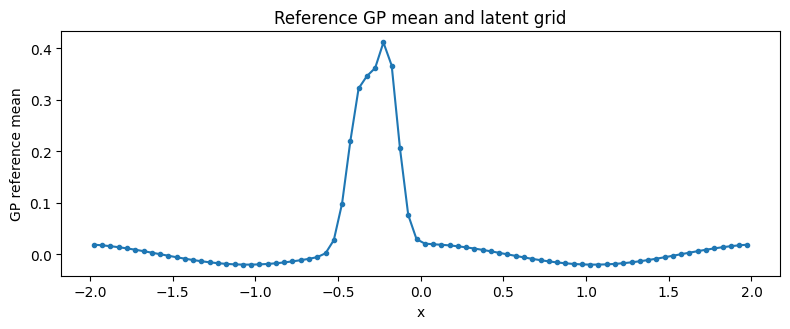

In [2]:
radii = (np.arange(N_FACTORS) + 0.5) * DX
x_latent = np.concatenate([-radii[::-1], radii])

def reference_mean(x):
    x = np.asarray(x)
    return (
        0.36 * np.exp(-0.5 * ((x + 0.20) / 0.065) ** 2)
        + 0.31 * np.exp(-0.5 * ((x + 0.36) / 0.075) ** 2)
        + 0.02 * np.cos(3.0 * x)
    )

K = np.exp(-np.abs(x_latent[:, None] - x_latent[None, :]) / ELL)
Q = np.linalg.inv(K)
m_latent = reference_mean(x_latent)

L = np.linalg.cholesky(K + 1e-12 * np.eye(len(x_latent)))
Y = m_latent + rng.standard_normal((N_SAMPLES, len(x_latent))) @ L.T

# block j contains {-r_j,+r_j}
blocks = [(N_FACTORS - 1 - j, N_FACTORS + j) for j in range(N_FACTORS)]

plt.figure(figsize=(8, 3.4))
plt.plot(x_latent, m_latent, marker="o", ms=3)
plt.xlabel("x")
plt.ylabel("GP reference mean")
plt.title("Reference GP mean and latent grid")
plt.tight_layout()
plt.show()

## 3. Cheap certified influence matrix

For each block \(i\), define

\[
\rho_i=\lambda_{\min}(Q_{ii}),
\qquad
\kappa_{ik}=\|Q_{ik}\|_2,
\]

and build

\[
A_{ii}=\rho_i,
\qquad
A_{ik}=-\kappa_{ik}\quad (i\neq k).
\]

Because the symmetry penalty is convex and internal to a block, activating any subset of factors can only increase within-block curvature and introduces no new cross-block Hessian. The exponential utility adds only a linear tilt. Thus this same \(A\) remains a conservative influence matrix throughout the relevant interpolation.

For

\[
e_j(f)=\gamma\log\cosh((f(r_j)-f(-r_j))/\tau),
\]

\[
\|\nabla_{Y_j}e_j\|
\le
L_e
=
\frac{\sqrt2\gamma}{\tau}.
\]

No conditioned sampling is needed for these constants.

In [3]:
rho = np.empty(N_FACTORS)
kappa = np.zeros((N_FACTORS, N_FACTORS))

for i, bi in enumerate(blocks):
    rho[i] = np.linalg.eigvalsh(Q[np.ix_(bi, bi)]).min()
    for j, bj in enumerate(blocks):
        if i != j:
            kappa[i, j] = np.linalg.norm(Q[np.ix_(bi, bj)], 2)

A = np.diag(rho) - kappa
lambda_min_A = np.linalg.eigvalsh(A).min()
assert lambda_min_A > 0

L_FACTOR = GAMMA * np.sqrt(2.0) / TAU

print(f"lambda_min(A) = {lambda_min_A:.6f} > 0")
print(f"Global factor-gradient bound L_e = {L_FACTOR:.6f}")

lambda_min(A) = 0.199036 > 0
Global factor-gradient bound L_e = 0.141421


## 4. Lazy factor evaluation

The screening algorithm knows each factor's **block and analytic bound**, but it does **not** evaluate the energy of an omitted factor on the Monte Carlo samples.

A factor energy is evaluated only when that factor is activated.

At the end of the notebook we deliberately compute all 40 factors once as held-out validation.

In [4]:
factor_cache = {}

def factor_energy(j):
    """Evaluate factor j only after the adaptive algorithm activates it."""
    if j not in factor_cache:
        i_minus, i_plus = blocks[j]
        delta = Y[:, i_plus] - Y[:, i_minus]
        factor_cache[j] = GAMMA * np.log(np.cosh(delta / TAU))
    return factor_cache[j]

def active_logweights(active):
    if not active:
        return np.zeros(N_SAMPLES)

    E = np.zeros(N_SAMPLES)
    for j in sorted(active):
        E += factor_energy(j)
    return -E

## 5. Acquisition at an arbitrary action \(x\)

For the OU process,

\[
f(x)\mid Y
\sim
\mathcal N(\mu_x(Y),\sigma_x^2).
\]

Hence

\[
\widetilde u_x(Y)
=
\mathbb E[e^{\beta f(x)}\mid Y]
=
\exp\!\left(
\beta\mu_x(Y)+\frac{\beta^2\sigma_x^2}{2}
\right).
\]

The sparse acquisition is

\[
\alpha_S(x)
=
\mathbb E_{\pi_S}[\widetilde u_x(Y)].
\]

Here it is estimated using common-random-number importance sampling from the Gaussian reference. In a FlowGP implementation, this role would be played by the sparse conditioned sampler.

In [5]:
def action_representation(x):
    """
    Return a such that
      E[f(x)|Y] = m(x) + a^T(Y-m_grid),
    plus Var[f(x)|Y].
    """
    x = float(x)
    exact = np.flatnonzero(np.isclose(x_latent, x, atol=1e-12))
    a = np.zeros(len(x_latent))

    if len(exact):
        a[exact[0]] = 1.0
        return a, 0.0

    j = np.searchsorted(x_latent, x)
    if j == 0 or j == len(x_latent):
        raise ValueError("Action lies outside the latent grid.")

    il, ir = j - 1, j
    xl, xr = x_latent[il], x_latent[ir]

    corr_lr = np.exp(-(xr - xl) / ELL)
    K2 = np.array([[1.0, corr_lr], [corr_lr, 1.0]])
    k = np.array([
        np.exp(-(x - xl) / ELL),
        np.exp(-(xr - x) / ELL),
    ])
    c = np.linalg.solve(K2, k)

    a[il], a[ir] = c
    cond_var = max(0.0, 1.0 - k @ c)
    return a, cond_var

def logalpha_curve(active, x_actions):
    """Estimate log alpha_S(x) across the action grid."""
    lw = active_logweights(active)
    logden = logsumexp(lw) - np.log(N_SAMPLES)

    vals = np.empty(len(x_actions))
    for k, x in enumerate(x_actions):
        a, cond_var = action_representation(x)
        nz = np.flatnonzero(a)

        mu = reference_mean(x)
        for idx in nz:
            mu = mu + a[idx] * (Y[:, idx] - m_latent[idx])

        lognum = (
            logsumexp(lw + BETA * mu + 0.5 * BETA**2 * cond_var)
            - np.log(N_SAMPLES)
        )
        vals[k] = lognum - logden

    return vals

x_actions = np.linspace(ACTION_MIN, ACTION_MAX, N_ACTIONS)

## 6. One leader, one challenger objective

If \(a(x)\) is the conditional-mean coefficient vector, the block decision footprint is

\[
d_i(\widehat x,x)
=
\beta
\left\|
[a(x)-a(\widehat x)]_{Y_i}
\right\|_2.
\]

Let \(h_U\) contain \(L_e\) on omitted-factor blocks and zero on active blocks.

The covariance comparison bound is

\[
B_S(\widehat x,x)
=
h_U^\top A^{-1}d(\widehat x,x).
\]

Because \(A\) is symmetric, solve once:

\[
Aw=h_U,
\]

then every challenger evaluation is just

\[
\boxed{
B_S(\widehat x,x)=w^\top d(\widehat x,x).
}
\]

So evaluating many possible challengers does not require rerunning conditioning or solving a new influence system each time.

In [6]:
def decision_footprint(xhat, x):
    a_hat, _ = action_representation(xhat)
    a_x, _ = action_representation(x)
    diff = BETA * (a_x - a_hat)

    return np.array([
        np.linalg.norm(diff[list(block)])
        for block in blocks
    ])

def screening_vector(active):
    h_U = np.full(N_FACTORS, L_FACTOR)
    if active:
        h_U[list(active)] = 0.0
    return np.linalg.solve(A, h_U)

def structural_bound(xhat, x, w):
    return float(w @ decision_footprint(xhat, x))

def state_for_active_set(active):
    # 1) maximize sparse acquisition
    loga = logalpha_curve(active, x_actions)
    i_hat = int(np.argmax(loga))
    xhat = float(x_actions[i_hat])

    # 2) one influence solve for all challengers
    w = screening_vector(active)
    bounds = np.array([
        structural_bound(xhat, x, w)
        for x in x_actions
    ])

    # 3) optimistic full-conditioning challenger envelope
    C = loga - loga[i_hat] + bounds
    epsilon = max(0.0, float(C.max()))

    # best distinct challenger
    candidates = np.arange(len(x_actions))
    candidates = candidates[candidates != i_hat]
    i_ch = int(candidates[np.argmax(C[candidates])])

    return {
        "xhat": xhat,
        "xchallenger": float(x_actions[i_ch]),
        "epsilon": epsilon,
        "logalpha": loga,
        "bounds": bounds,
        "envelope": C,
        "i_hat": i_hat,
        "i_ch": i_ch,
    }

## 7. Adaptive factor activation

If the certificate is not yet small enough, inspect only the **current worst challenger** \(x_c\).

Solve

\[
Av=d(\widehat x,x_c).
\]

The omitted factor \(j\) contributes at most

\[
b_j=L_e v_j
\]

to this unresolved comparison. We activate the few omitted factors with the largest \(b_j\), update the sparse acquisition, and repeat.

In [7]:
active = set()
history = []
states = []

for iteration in range(20):
    state = state_for_active_set(active)
    states.append(state)

    xhat = state["xhat"]
    xc = state["xchallenger"]
    eps = state["epsilon"]
    i_ch = state["i_ch"]

    # Factor-wise contributions for the SINGLE worst challenger.
    d = decision_footprint(xhat, xc)
    v = np.linalg.solve(A, d)
    per_factor = L_FACTOR * v

    omitted = [j for j in range(N_FACTORS) if j not in active]
    ranked = sorted(omitted, key=lambda j: per_factor[j], reverse=True)
    to_add = ranked[:BATCH_ADD]

    history.append({
        "iteration": iteration,
        "active_M": len(active),
        "x_hat": xhat,
        "x_challenger": xc,
        "epsilon_certificate": eps,
        "challenger_sparse_gap":
            state["logalpha"][i_ch] - state["logalpha"][state["i_hat"]],
        "challenger_structural_bound": state["bounds"][i_ch],
        "factors_to_add": to_add,
        "orbit_radii_to_add": [round(float(radii[j]), 3) for j in to_add],
    })

    if eps <= EPS_TARGET:
        break

    active.update(to_add)

history_df = pd.DataFrame(history)
history_df

,iteration,active_M,x_hat,x_challenger,epsilon_certificate,challenger_sparse_gap,challenger_structural_bound,factors_to_add,orbit_radii_to_add
0,0,0,-0.2134,-0.2758,0.954500,-0.040951,0.995451,"[5, 4, 3]","[0.275, 0.225, 0.175]"
1,1,3,-0.2082,-0.3746,0.624984,-0.041589,0.666573,"[7, 6, 8]","[0.375, 0.325, 0.425]"
2,2,6,-0.2069,-0.1250,0.349438,-0.122569,0.472007,"[2, 1, 0]","[0.125, 0.075, 0.025]"
3,3,9,-0.2082,-0.5761,0.201158,-0.246760,0.447918,"[11, 10, 12]","[0.575, 0.525, 0.625]"
4,4,12,-0.2082,-0.3590,0.026141,-0.056726,0.082867,"[9, 13, 14]","[0.475, 0.675, 0.725]"


### How to read the adaptive table

- `x_hat` is the current sparse-acquisition maximizer.
- `x_challenger` maximizes the optimistic envelope \(C_S(x)\).
- `challenger_sparse_gap` is negative because the sparse model prefers \(\widehat x\).
- `challenger_structural_bound` is how much omitted information could repair that gap.
- `epsilon_certificate` is the largest optimistic advantage anywhere in the action domain.
- `factors_to_add` are the factors most responsible for the current worst unresolved comparison.

The challenger is allowed to move as the algorithm resolves different sources of uncertainty.

In [8]:
print(f"Stopped with M = {len(active)} active factors out of {N_FACTORS}.")
print("Factor energies evaluated before held-out validation:")
print(sorted(factor_cache.keys()))

final_state = states[-1]

print()
print(f"x_hat      = {final_state['xhat']:.4f}")
print(f"challenger = {final_state['xchallenger']:.4f}")
print(f"epsilon    = {final_state['epsilon']:.6f}")
print(
    "Certified acquisition fraction >= "
    f"{np.exp(-final_state['epsilon']):.4%} of the fully conditioned optimum"
)

Stopped with M = 12 active factors out of 40.
Factor energies evaluated before held-out validation:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12]

x_hat      = -0.2082
challenger = -0.3590
epsilon    = 0.026141
Certified acquisition fraction >= 97.4198% of the fully conditioned optimum


## 8. Held-out full-conditioning validation

Everything above used only active factor energies plus analytic influence bounds.

Now compute all 40 factor energies **only as validation**. This step is not needed by the adaptive screen.

In [9]:
def full_validation_logweights():
    E = np.zeros(N_SAMPLES)
    for j in range(N_FACTORS):
        i_minus, i_plus = blocks[j]
        delta = Y[:, i_plus] - Y[:, i_minus]
        E += GAMMA * np.log(np.cosh(delta / TAU))
    return -E

def logalpha_curve_from_logweights(lw, x_actions):
    logden = logsumexp(lw) - np.log(N_SAMPLES)
    vals = np.empty(len(x_actions))

    for k, x in enumerate(x_actions):
        a, cond_var = action_representation(x)
        nz = np.flatnonzero(a)

        mu = reference_mean(x)
        for idx in nz:
            mu = mu + a[idx] * (Y[:, idx] - m_latent[idx])

        lognum = (
            logsumexp(lw + BETA * mu + 0.5 * BETA**2 * cond_var)
            - np.log(N_SAMPLES)
        )
        vals[k] = lognum - logden

    return vals

full_logalpha = logalpha_curve_from_logweights(
    full_validation_logweights(),
    x_actions,
)

i_full = int(np.argmax(full_logalpha))
x_full = float(x_actions[i_full])
i_sparse_hat = final_state["i_hat"]

actual_log_regret = float(
    full_logalpha[i_full] - full_logalpha[i_sparse_hat]
)

summary = pd.DataFrame([{
    "total_factors_N": N_FACTORS,
    "active_factors_M": len(active),
    "x_hat_sparse": final_state["xhat"],
    "x_challenger": final_state["xchallenger"],
    "epsilon_certificate": final_state["epsilon"],
    "certified_fraction": np.exp(-final_state["epsilon"]),
    "full_validation_x_star": x_full,
    "actual_full_log_regret_at_x_hat": actual_log_regret,
    "lambda_min_A": lambda_min_A,
}])

summary

,total_factors_N,active_factors_M,x_hat_sparse,x_challenger,epsilon_certificate,certified_fraction,full_validation_x_star,actual_full_log_regret_at_x_hat,lambda_min_A
0,40,12,-0.2082,-0.359,0.026141,0.974198,-0.2082,0.0,0.199036


## 9. Final envelope figure

The key curve is

\[
C_S(x)
=
\log\alpha_S(x)-\log\alpha_S(\widehat x)+B_S(\widehat x,x).
\]

It is an optimistic upper bound on how much better any action could be than \(\widehat x\) after all omitted scientific information is incorporated.

The full-conditioning curve is plotted only afterward to verify what actually happened.

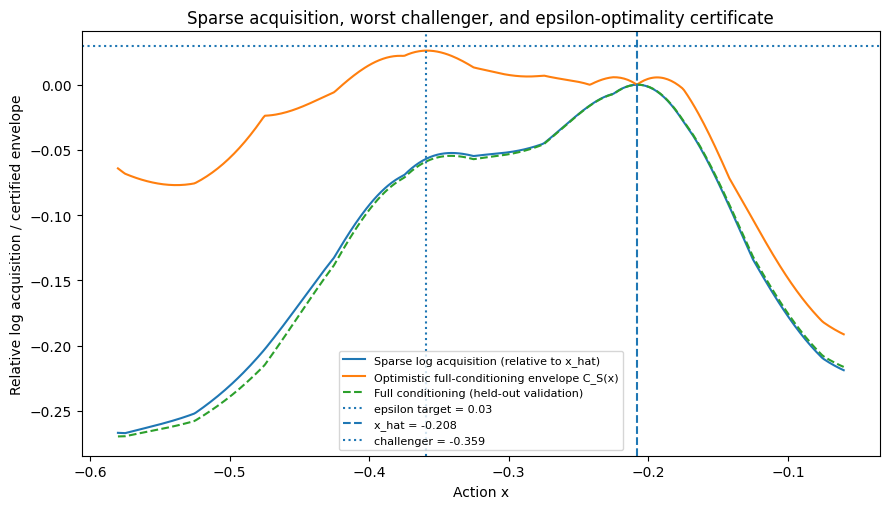

Saved: /mnt/data/dec_symmetry_outputs/final_envelope.png


In [10]:
rel_sparse = (
    final_state["logalpha"]
    - final_state["logalpha"][final_state["i_hat"]]
)
rel_full = full_logalpha - full_logalpha[i_full]

plt.figure(figsize=(9, 5.2))
plt.plot(
    x_actions,
    rel_sparse,
    label="Sparse log acquisition (relative to x_hat)",
)
plt.plot(
    x_actions,
    final_state["envelope"],
    label="Optimistic full-conditioning envelope C_S(x)",
)
plt.plot(
    x_actions,
    rel_full,
    linestyle="--",
    label="Full conditioning (held-out validation)",
)
plt.axhline(
    EPS_TARGET,
    linestyle=":",
    label=f"epsilon target = {EPS_TARGET:.2f}",
)
plt.axvline(
    final_state["xhat"],
    linestyle="--",
    label=f"x_hat = {final_state['xhat']:.3f}",
)
plt.axvline(
    final_state["xchallenger"],
    linestyle=":",
    label=f"challenger = {final_state['xchallenger']:.3f}",
)
plt.xlabel("Action x")
plt.ylabel("Relative log acquisition / certified envelope")
plt.title("Sparse acquisition, worst challenger, and epsilon-optimality certificate")
plt.legend(fontsize=8)
plt.tight_layout()

fig_path = OUTPUT_DIR / "final_envelope.png"
plt.savefig(fig_path, dpi=180)
plt.show()

print(f"Saved: {fig_path}")

## 10. Adaptive path

The algorithm repeatedly asks:

> **What unresolved action could still beat the current leader, and which omitted scientific factors are responsible for that possibility?**

The first plot shows how the certificate shrinks. The second shows which symmetry orbits were activated.

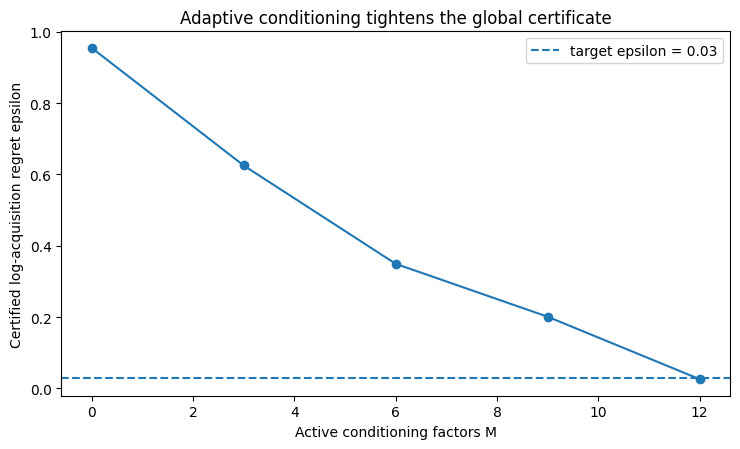

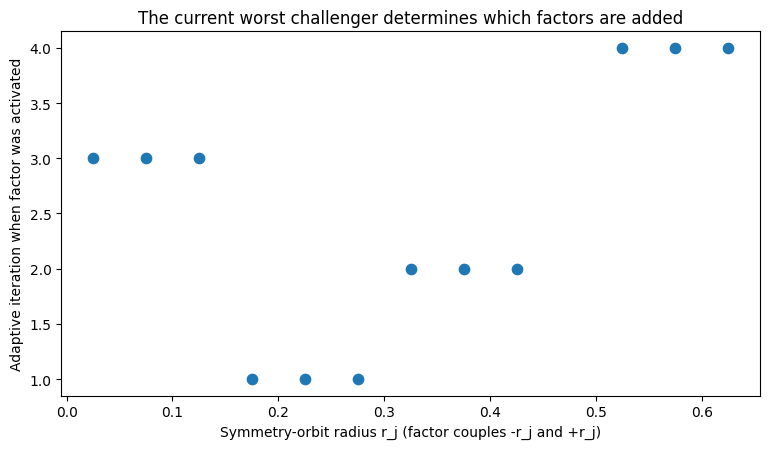

Saved: /mnt/data/dec_symmetry_outputs/epsilon_path.png
Saved: /mnt/data/dec_symmetry_outputs/factor_activation_path.png


In [11]:
plt.figure(figsize=(7.5, 4.6))
plt.plot(
    history_df["active_M"],
    history_df["epsilon_certificate"],
    marker="o",
)
plt.axhline(
    EPS_TARGET,
    linestyle="--",
    label=f"target epsilon = {EPS_TARGET:.2f}",
)
plt.xlabel("Active conditioning factors M")
plt.ylabel("Certified log-acquisition regret epsilon")
plt.title("Adaptive conditioning tightens the global certificate")
plt.legend()
plt.tight_layout()

path1 = OUTPUT_DIR / "epsilon_path.png"
plt.savefig(path1, dpi=180)
plt.show()

activation_iteration = np.full(N_FACTORS, np.nan)
for row in history:
    if row["epsilon_certificate"] <= EPS_TARGET:
        break
    for j in row["factors_to_add"]:
        if np.isnan(activation_iteration[j]):
            activation_iteration[j] = row["iteration"] + 1

mask = ~np.isnan(activation_iteration)

plt.figure(figsize=(7.8, 4.6))
plt.scatter(
    radii[mask],
    activation_iteration[mask],
    s=55,
)
plt.xlabel("Symmetry-orbit radius r_j (factor couples -r_j and +r_j)")
plt.ylabel("Adaptive iteration when factor was activated")
plt.title("The current worst challenger determines which factors are added")
plt.tight_layout()

path2 = OUTPUT_DIR / "factor_activation_path.png"
plt.savefig(path2, dpi=180)
plt.show()

print(f"Saved: {path1}")
print(f"Saved: {path2}")

## 11. Interpretation

With the default parameters and random seed, this notebook should reproduce approximately:

- total factors: \(N=40\);
- active factors at stopping: \(M=12\);
- sparse maximizer:
  \[
  \widehat x \approx -0.208;
  \]
- worst remaining challenger:
  \[
  x_c \approx -0.359;
  \]
- certificate:
  \[
  \epsilon\approx 0.0261;
  \]
- therefore
  \[
  \alpha_{\rm full}(\widehat x)
  \ge
  e^{-0.0261}\alpha_{\rm full}(x^\star)
  \approx
  0.974\,\alpha_{\rm full}(x^\star).
  \]

The held-out full-conditioning calculation chooses the same action on the dense action grid, so the observed full-model acquisition regret is zero in this run.

### What this demonstrates

The important computational separation is that **only 12 factor energies are ever evaluated by the adaptive algorithm**. The other factors contribute through precomputed analytic influence constants and a small linear solve.

### What remains simplified

1. The dense action grid is a transparent stand-in for a continuous acquisition/challenger optimizer.
2. The plotted certificate accounts for structural-conditioning error, not Monte Carlo error. A practical method should add MC / flow / optimizer errors as separate terms.
3. This is a favorable symmetry example: the factors are convex and become intra-block after grouping symmetry orbits.
4. The next stress test should use overlapping nonlinear PDE residual factors, where several factors share the same function coordinates.

In [12]:
history_df.to_csv(OUTPUT_DIR / "adaptive_history.csv", index=False)
summary.to_csv(OUTPUT_DIR / "summary.csv", index=False)

print("Output directory:", OUTPUT_DIR)
for p in sorted(OUTPUT_DIR.iterdir()):
    print(" -", p.name)

Output directory: /mnt/data/dec_symmetry_outputs
 - adaptive_history.csv
 - epsilon_path.png
 - factor_activation_path.png
 - final_envelope.png
 - summary.csv
